# Dry Run Analysis — Kalshi BTC 15m Strategy

**Configurable parameters** (change at the top of the notebook, then re-run all cells):
- `EV_THRESHOLD` — only ticks with `ev >= EV_THRESHOLD` are included in the analysis
- `FEE_COEFF = 0.07` — Kalshi fee coefficient; full formula: `fee = ceil(FEE_COEFF × P × (1−P) × 100) / 100`

**Fixed filters** (applied when CSVs are written, not adjustable here):
- Crossed-book rows removed (`best_yes_ask + best_no_ask >= 1`)
- `depth_ok == True` (top-3 orderbook depth ≥ $500 for the traded side)

**Data note:** CSVs from before the fee-formula update (flat FEE=0.07) have `signal_side` inferred  
via EV-matching and are unreliable. CSVs from later runs have `signal_side` recorded directly.

In [47]:
import math
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)

# Kalshi fee coefficient. Full per-contract fee formula:
#   fee = ceil(FEE_COEFF × P × (1−P) × 100) / 100
# where P is the contract price and ceil rounds up to the next cent.
FEE_COEFF    = 0.07
EV_THRESHOLD = 0.04

def kalshi_fee(price):
    """Fee per contract (dollars) for a market order at the given price."""
    return np.ceil(FEE_COEFF * price * (1 - price) * 100) / 100

## 1. Load & Overview

In [48]:
logs_dir  = Path("dry_run_logs")
csv_files = sorted(logs_dir.glob("*.csv"))

frames = []
for f in csv_files:
    tmp = pd.read_csv(f, parse_dates=["timestamp_utc"])
    print(f"{f.name}: {len(tmp):,} rows")
    frames.append(tmp)

raw = pd.concat(frames, ignore_index=True)
raw["depth_ok"] = raw["depth_ok"].astype(str).str.strip().str.lower() == "true"

print(f"\nTotal rows (all logged signals): {len(raw):,}")
print(f"Windows covered:                 {raw['ticker'].nunique()}")
print(f"Date range: {raw['timestamp_utc'].min()} -> {raw['timestamp_utc'].max()}")

dry_run_20260603_034455_001.csv: 437 rows
dry_run_20260603_044455_002.csv: 263 rows
dry_run_20260603_054455_003.csv: 188 rows
dry_run_20260603_064455_004.csv: 691 rows
dry_run_20260603_074455_005.csv: 227 rows
dry_run_20260603_084455_006.csv: 499 rows
dry_run_20260603_094455_007.csv: 0 rows
dry_run_20260603_104455_008.csv: 359 rows
dry_run_20260603_114455_009.csv: 707 rows
dry_run_20260603_124455_010.csv: 0 rows
dry_run_20260603_134455_011.csv: 187 rows
dry_run_20260603_144455_012.csv: 48 rows
dry_run_20260603_154455_013.csv: 424 rows
dry_run_20260603_164455_014.csv: 34 rows
dry_run_20260603_174455_015.csv: 145 rows
dry_run_20260603_184455_016.csv: 136 rows
dry_run_20260603_194455_017.csv: 81 rows
dry_run_20260603_204455_018.csv: 1 rows
dry_run_20260603_214455_019.csv: 3 rows
dry_run_20260603_224455_020.csv: 0 rows
dry_run_20260604_204455_001.csv: 477 rows
dry_run_20260604_214455_002.csv: 368 rows
dry_run_20260604_224455_003.csv: 1 rows
dry_run_20260604_234455_004.csv: 135 rows
dry_run

C:\Users\user\AppData\Local\Temp\ipykernel_11548\1361264067.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  raw = pd.concat(frames, ignore_index=True)


In [49]:
# Apply filters — depth_ok AND ev >= EV_THRESHOLD
# Adjusting EV_THRESHOLD or FEE_COEFF at the top of the notebook re-filters
# the entire analysis without touching the CSVs.
df = raw[raw["depth_ok"] & (raw["ev"] >= EV_THRESHOLD)].copy()

print(f"EV_THRESHOLD = {EV_THRESHOLD}   FEE_COEFF = {FEE_COEFF}  (fee = ceil(0.07 × P × (1−P) × 100)/100)")
print(f"After depth_ok + EV >= {EV_THRESHOLD}: {len(df):,} rows  ({len(df)/len(raw)*100:.1f}% of raw)")

print(f"\nPer-window overview:")
win_summary = (
    df.groupby("ticker")
    .agg(
        ticks        =("timestamp_utc",   "count"),
        resolution   =("resolution",       "first"),
        s0_price     =("s0_price",         "first"),
        vol_estimate =("vol_estimate",     "first"),
        realized_vol =("realized_vol",     "first"),
    )
    .reset_index()
)
print(win_summary.to_string(index=False))

EV_THRESHOLD = 0.04   FEE_COEFF = 0.07  (fee = ceil(0.07 × P × (1−P) × 100)/100)
After depth_ok + EV >= 0.04: 76,063 rows  (72.6% of raw)

Per-window overview:
                 ticker  ticks resolution     s0_price  vol_estimate  realized_vol
KXBTC15M-26JUN022330-30    219         no 66400.680000      0.000103      0.000119
KXBTC15M-26JUN022345-45    218         no 66055.210000      0.000110      0.000166
KXBTC15M-26JUN030015-15     85        yes 65770.850000      0.000150      0.000163
KXBTC15M-26JUN030045-45     72         no 66508.580000      0.000125      0.000147
KXBTC15M-26JUN030115-15    156        yes 66382.720000      0.000125      0.000181
KXBTC15M-26JUN030230-30    573        yes 67073.780000      0.000124      0.000110
KXBTC15M-26JUN030245-45     92        yes 67172.250000      0.000116      0.000124
KXBTC15M-26JUN030300-00     50         no 67247.320000      0.000119      0.000116
KXBTC15M-26JUN030315-15     24        yes 66906.510000      0.000119      0.000094
KXBTC15M-2

## 2. Model Accuracy

A tick is **correct** when `trade_direction == resolution`.  
Every valid signal tick is counted independently — not deduplicated to one per window.

In [50]:
# signal_side is now recorded directly in the CSV at log time,
# so no EV-matching inference is needed.
# For CSVs from old runs that pre-date this column, fall back to EV matching.
if "signal_side" in df.columns and df["signal_side"].notna().all():
    pass  # already present — use as-is
else:
    fee_yes = kalshi_fee(df["best_yes_ask"])
    fee_no  = kalshi_fee(df["best_no_ask"])
    _ev_yes = (1 - fee_yes - df["best_yes_ask"]) * df["p_up"] \
              - df["best_yes_ask"] * (1 - df["p_up"])
    _ev_no  = (1 - fee_no  - df["best_no_ask"])  * (1 - df["p_up"]) \
              - df["best_no_ask"]  * df["p_up"]
    df["signal_side"] = np.where(
        (df["ev"] - _ev_yes).abs() < (df["ev"] - _ev_no).abs(),
        "yes", "no"
    )
    print("NOTE: signal_side inferred from EV matching (old data — may be unreliable).")

df["correct"] = df["signal_side"] == df["resolution"]

overall_acc   = df["correct"].mean()
overall_n     = len(df)
overall_right = df["correct"].sum()

print("=" * 50)
print(f"  OVERALL ACCURACY: {overall_acc:.2%}")
print(f"  ({overall_right:,} correct out of {overall_n:,} ticks)")
print("=" * 50)

acc_by_dir = (
    df.groupby("signal_side")["correct"]
    .agg(accuracy="mean", ticks="count", correct_n="sum")
)
print("\nBy signal side:")
print(acc_by_dir.to_string())

acc_by_win = (
    df.groupby(["ticker", "resolution"])["correct"]
    .agg(accuracy="mean", ticks="count")
    .reset_index()
)
print("\nBy window:")
print(acc_by_win.to_string(index=False))

NOTE: signal_side inferred from EV matching (old data — may be unreliable).
  OVERALL ACCURACY: 44.76%
  (34,043 correct out of 76,063 ticks)

By signal side:
             accuracy  ticks  correct_n
signal_side                            
no           0.474279  65879      31245
yes          0.274745  10184       2798

By window:
                 ticker resolution  accuracy  ticks
KXBTC15M-26JUN022330-30         no  1.000000    219
KXBTC15M-26JUN022345-45         no  1.000000    218
KXBTC15M-26JUN030015-15        yes  0.000000     85
KXBTC15M-26JUN030045-45         no  0.000000     72
KXBTC15M-26JUN030115-15        yes  0.000000    156
KXBTC15M-26JUN030230-30        yes  0.000000    573
KXBTC15M-26JUN030245-45        yes  1.000000     92
KXBTC15M-26JUN030300-00         no  0.000000     50
KXBTC15M-26JUN030315-15        yes  1.000000     24
KXBTC15M-26JUN030445-45        yes  0.000000    355
KXBTC15M-26JUN030645-45         no  1.000000    314
KXBTC15M-26JUN030715-15        yes  0.000000 

## 3. Profitability per Share

| Outcome | Formula | Notes |
|---|---|---|
| Correct (direction == resolution) | `1 − fee − ask` | Receive \$1, pay ask + fee on win |
| Wrong   (direction ≠  resolution) | `−ask`          | Lose the premium; no fee on a loss |

In [51]:
from scipy.stats import ttest_1samp

# Entry price = best_yes_ask for YES signals, best_no_ask for NO signals
df["entry_ask"] = np.where(df["signal_side"] == "yes",
                           df["best_yes_ask"], df["best_no_ask"])

# Fee is price-dependent: ceil(0.07 × P × (1-P) × 100) / 100
df["entry_fee"] = kalshi_fee(df["entry_ask"])

df["pnl_per_share"] = np.where(
    df["correct"],
    1 - df["entry_fee"] - df["entry_ask"],
    -df["entry_ask"]
)

# ══════════════════════════════════════════════════════════
#  FIRST-ENTRY HELD-TO-EXPIRY P&L
#  Enter at the first qualifying tick per window, hold
#  until resolution.  One independent observation per window.
# ══════════════════════════════════════════════════════════

# For ties on time, prefer the higher-EV signal
first = (
    df.sort_values(["time_elapsed_s", "ev"], ascending=[True, False])
    .groupby("ticker", as_index=False)
    .first()
)

first["held_pnl"] = np.where(
    first["correct"],
    1 - first["entry_fee"] - first["entry_ask"],
    -first["entry_ask"]
)

n_windows   = len(first)
win_rate    = first["correct"].mean()
total_cost  = first["entry_ask"].sum()
pct_return  = first["held_pnl"].sum() / total_cost * 100

print("FIRST-ENTRY HELD-TO-EXPIRY P&L")
print("(enter at first qualifying tick per window, hold to expiry)")
print("=" * 55)
print(f"  Windows with >=1 signal:  {n_windows}")
print(f"  Win rate (correct side):  {win_rate:.2%}")
print(f"  MEAN P&L PER TRADE:       ${first['held_pnl'].mean():.6f}")
print(f"  MEDIAN P&L PER TRADE:     ${first['held_pnl'].median():.6f}")
print(f"  STD:                      ${first['held_pnl'].std():.6f}")
print(f"  TOTAL RETURN:             {pct_return:.2f}%  (sum P&L / total capital deployed)")
print("=" * 55)

# t-test: each window is a genuinely independent observation
t_held, p_held_two = ttest_1samp(first["held_pnl"].dropna(), 0)
p_held_one = p_held_two / 2
print(f"\n  Window-level t-test (n={n_windows} — each obs is independent)")
print(f"  t = {t_held:.3f}   p (two-tailed) = {p_held_two:.4f}   p (one-tailed) = {p_held_one:.4f}")

print("\nPer-window breakdown:")
held_detail = first[["ticker", "resolution", "signal_side",
                      "time_elapsed_s", "entry_ask", "entry_fee",
                      "correct", "held_pnl"]].copy()
held_detail["time_elapsed_s"] = held_detail["time_elapsed_s"].round(1)
held_detail["entry_ask"]      = held_detail["entry_ask"].round(4)
held_detail["entry_fee"]      = held_detail["entry_fee"].round(4)
held_detail["held_pnl"]       = held_detail["held_pnl"].round(4)
print(held_detail.to_string(index=False))

FIRST-ENTRY HELD-TO-EXPIRY P&L
(enter at first qualifying tick per window, hold to expiry)
  Windows with >=1 signal:  528
  Win rate (correct side):  42.80%
  MEAN P&L PER TRADE:       $0.029856
  MEDIAN P&L PER TRADE:     $-0.250000
  STD:                      $0.474889
  TOTAL RETURN:             7.66%  (sum P&L / total capital deployed)

  Window-level t-test (n=528 — each obs is independent)
  t = 1.445   p (two-tailed) = 0.1492   p (one-tailed) = 0.0746

Per-window breakdown:
                 ticker resolution signal_side  time_elapsed_s  entry_ask  entry_fee  correct  held_pnl
KXBTC15M-26JUN022330-30         no          no       72.200000   0.180000   0.020000     True  0.800000
KXBTC15M-26JUN022345-45         no          no       72.100000   0.240000   0.020000     True  0.740000
KXBTC15M-26JUN030015-15        yes          no       72.600000   0.220000   0.020000    False -0.220000
KXBTC15M-26JUN030045-45         no         yes       72.100000   0.130000   0.010000    False -0.

## 3b. Returns Distribution (First-Entry, Held to Expiry)

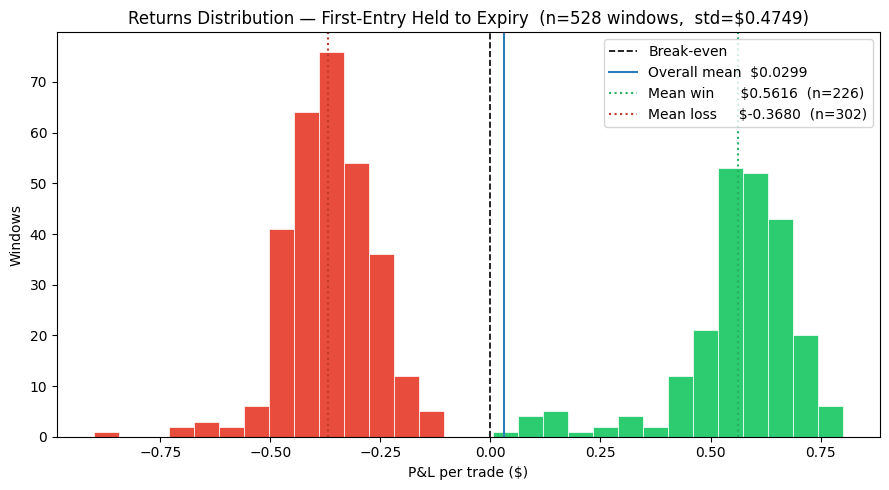

In [52]:
# ── Histogram of P&L per trade (first-entry held to expiry) ──────────────────
pnl      = first["held_pnl"].dropna()
wins     = pnl[pnl > 0]
losses   = pnl[pnl <= 0]

mean_win  = wins.mean()   if len(wins)   > 0 else float("nan")
mean_loss = losses.mean() if len(losses) > 0 else float("nan")

fig, ax = plt.subplots(figsize=(9, 5))

counts, edges = np.histogram(pnl, bins=30)
for left, right, count in zip(edges[:-1], edges[1:], counts):
    color = "#2ecc71" if (left + right) / 2 >= 0 else "#e74c3c"
    ax.bar(left, count, width=(right - left), color=color,
           edgecolor="white", linewidth=0.5, align="edge")

ax.axvline(0,          color="black",   linewidth=1.2, linestyle="--", label="Break-even")
ax.axvline(pnl.mean(), color="#2980b9", linewidth=1.5, linestyle="-",
           label=f"Overall mean  ${pnl.mean():.4f}")
ax.axvline(mean_win,   color="#27ae60", linewidth=1.5, linestyle=":",
           label=f"Mean win      ${mean_win:.4f}  (n={len(wins)})")
ax.axvline(mean_loss,  color="#c0392b", linewidth=1.5, linestyle=":",
           label=f"Mean loss     ${mean_loss:.4f}  (n={len(losses)})")

ax.set_xlabel("P&L per trade ($)")
ax.set_ylabel("Windows")
ax.set_title(
    f"Returns Distribution — First-Entry Held to Expiry  "
    f"(n={len(pnl)} windows,  std=${pnl.std():.4f})"
)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Volatility: Implied (vol_estimate) vs Realized

`vol_estimate` — per-√second GBM vol derived from the **prior** window's Coinbase price data.  
`realized_vol` — per-√second vol actually observed in **this** window (computed from logged Coinbase prices).  

Both columns are constant within a window; the regression uses one observation per window.

In [53]:
vol_df = (
    df.groupby("ticker")[["vol_estimate", "realized_vol"]]
    .first()
    .dropna()
    .reset_index()
)

print(f"Windows with both vol columns: {len(vol_df)}")
print(vol_df.to_string(index=False))

Windows with both vol columns: 528
                 ticker  vol_estimate  realized_vol
KXBTC15M-26JUN022330-30      0.000103      0.000119
KXBTC15M-26JUN022345-45      0.000110      0.000166
KXBTC15M-26JUN030015-15      0.000150      0.000163
KXBTC15M-26JUN030045-45      0.000125      0.000147
KXBTC15M-26JUN030115-15      0.000125      0.000181
KXBTC15M-26JUN030230-30      0.000124      0.000110
KXBTC15M-26JUN030245-45      0.000116      0.000124
KXBTC15M-26JUN030300-00      0.000119      0.000116
KXBTC15M-26JUN030315-15      0.000119      0.000094
KXBTC15M-26JUN030445-45      0.000082      0.000109
KXBTC15M-26JUN030645-45      0.000125      0.000103
KXBTC15M-26JUN030715-15      0.000104      0.000089
KXBTC15M-26JUN030730-30      0.000094      0.000093
KXBTC15M-26JUN030745-45      0.000092      0.000081
KXBTC15M-26JUN030915-15      0.000107      0.000112
KXBTC15M-26JUN030930-30      0.000110      0.000133
KXBTC15M-26JUN031045-45      0.000160      0.000149
KXBTC15M-26JUN031100-00      

In [54]:
x = vol_df["vol_estimate"].values
y = vol_df["realized_vol"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("=" * 55)
print("  Regression: realized_vol = slope * vol_estimate + intercept")
print(f"  slope:      {slope:.4f}")
print(f"  intercept:  {intercept:.8f}")
print(f"  R:          {r_value:.4f}")
print(f"  R²:         {r_value**2:.4f}")
print(f"  p-value:    {p_value:.4f}")
print(f"  std_err:    {std_err:.6f}")
print("=" * 55)

mean_ratio = (y / x).mean() if (x > 0).all() else float("nan")
print(f"\n  Mean realized/implied ratio: {mean_ratio:.4f}")
print(f"  (ratio > 1 = market was more volatile than estimated)")

  Regression: realized_vol = slope * vol_estimate + intercept
  slope:      0.8391
  intercept:  0.00001288
  R:          0.8109
  R²:         0.6575
  p-value:    0.0000
  std_err:    0.026404

  Mean realized/implied ratio: 1.0143
  (ratio > 1 = market was more volatile than estimated)


## 5. Summary Table

In [55]:
summary = (
    df.groupby(["ticker", "resolution"])
    .apply(lambda g: pd.Series({
        "ticks":              len(g),
        "yes_signals":        (g["signal_side"] == "yes").sum(),
        "no_signals":         (g["signal_side"] == "no").sum(),
        "accuracy":           g["correct"].mean(),
        "mean_pnl_per_share": g["pnl_per_share"].mean(),
        "mean_ev":            g["ev"].mean(),
        "mean_entry_ask":     g["entry_ask"].mean(),
        "vol_estimate":       g["vol_estimate"].iloc[0],
        "realized_vol":       g["realized_vol"].iloc[0],
    }), include_groups=False)
    .reset_index()
)

fmt = {
    "accuracy":            "{:.1%}".format,
    "mean_pnl_per_share":  "${:.5f}".format,
    "mean_ev":             "{:.5f}".format,
    "mean_entry_ask":      "{:.4f}".format,
    "vol_estimate":        "{:.2e}".format,
    "realized_vol":        "{:.2e}".format,
}
print(summary.to_string(index=False, formatters=fmt))

print("\n" + "=" * 60)
print(f"  Overall accuracy:               {df['correct'].mean():.2%}")
print(f"  Mean P&L per trade (1st entry): ${first['held_pnl'].mean():.6f}")
print(f"  Mean model EV:                  {df['ev'].mean():.6f}")
print("=" * 60)

                 ticker resolution       ticks  yes_signals  no_signals accuracy mean_pnl_per_share mean_ev mean_entry_ask vol_estimate realized_vol
KXBTC15M-26JUN022330-30         no  219.000000     0.000000  219.000000   100.0%           $0.83041 0.08671         0.1589     1.03e-04     1.19e-04
KXBTC15M-26JUN022345-45         no  218.000000     0.000000  218.000000   100.0%           $0.76124 0.06226         0.2188     1.10e-04     1.66e-04
KXBTC15M-26JUN030015-15        yes   85.000000     0.000000   85.000000     0.0%          $-0.22318 0.05020         0.2232     1.50e-04     1.63e-04
KXBTC15M-26JUN030045-45         no   72.000000    72.000000    0.000000     0.0%          $-0.12028 0.04571         0.1203     1.25e-04     1.47e-04
KXBTC15M-26JUN030115-15        yes  156.000000     0.000000  156.000000     0.0%          $-0.35218 0.05740         0.3522     1.25e-04     1.81e-04
KXBTC15M-26JUN030230-30        yes  573.000000     0.000000  573.000000     0.0%          $-0.33447 0.0687